# Práctica 3

Paso 0: Importar librerías

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import kendalltau, theilslopes

## PARTE I

### Ejercicio 1
Abrir los archivos de los 3 modelos y ambos escenarios, y consolidarlos en un solo dataset

In [ ]:
# Cargar los datos
# import gdown
# gdown.download_folder(id="1ZP-yqBKVZ8bYkbnxJL_hQpxl0qz9MP-6", output="datos_proyecciones", quiet=False)

In [2]:
# Definir función para abrir archivos
def cargar_historico(modelo, carpeta, variable):
    ruta = carpeta + modelo + f"/{variable}_{modelo}_1950-2014_historical.nc"
    return xr.open_dataset(ruta)[variable]

def cargar_escenario(modelo, escenario, carpeta, variable):
    carpeta_modelo = carpeta + modelo + "/"
    tramo1 = xr.open_dataset(carpeta_modelo + f"{variable}_{modelo}_2015-2049_{escenario}.nc")[variable]
    tramo2 = xr.open_dataset(carpeta_modelo + f"{variable}_{modelo}_2050-2099_{escenario}.nc")[variable]
    return xr.concat([tramo1, tramo2], dim="time")

In [9]:
# Definir variables para el llamado a los archivos
variable = "pr"
carpeta_datos = "C:/Users/sebas/OneDrive/Documentos/GitHub/geocomputacion/geocomputacion_-1GEO20-/ejercicios/ejercicios_aplicados/datos_proyecciones/"+variable+"/"

modelos = ["MPI-ESM1-2-LR", "NorESM2-LM", "IPSL-CM6A-LR"] # Modelos a trabajar
escenarios = ["ssp245", "ssp585"] # Escenarios

In [14]:
# Asignación de datos a variables de trabajo
ds = []
for modelo in modelos:
    historico = cargar_historico(modelo, carpeta_datos, variable)
    ds_por_escenario = []
    for escenario in escenarios:
        futuro = cargar_escenario(modelo, escenario, carpeta_datos, variable)
        ds_por_escenario.append(xr.concat([historico, futuro], dim="time"))
    serie_modelo = xr.concat(ds_por_escenario, dim="escenario")
    serie_modelo = serie_modelo.assign_coords(escenario=escenarios)
    ds.append(serie_modelo)

ds_base = xr.concat(ds, dim="modelo")
ds_base = ds_base.assign_coords(modelo=modelos)

In [15]:
# Visualización de datos
ds_base

<xarray.DataArray 'pr' (modelo: 3, escenario: 2, time: 1800, y: 100, x: 80)> Size: 346MB
array([[[[[        nan,         nan,         nan, ...,   5.265289 ,
             5.056358 ,   4.784719 ],
          [        nan,         nan,         nan, ...,   5.9010425,
             5.4093156,   4.871468 ],
          [        nan,         nan,         nan, ...,   9.968784 ,
             9.156126 ,   8.261883 ],
          ...,
          [        nan,         nan,         nan, ...,  50.10896  ,
            52.567497 ,  52.487404 ],
          [        nan,         nan,         nan, ...,  46.466743 ,
            47.77367  ,  48.47824  ],
          [        nan,         nan,         nan, ...,  45.024204 ,
            45.3109   ,  46.25985  ]],

         [[        nan,         nan,         nan, ...,  56.622135 ,
            58.18462  ,  59.285625 ],
          [        nan,         nan,         nan, ...,  64.29412  ,
            65.33802  ,  65.70331  ],
          [        nan,         nan,         nan, ...,  70.63271  ,
            71.03392  ,  70.72584  ],
...
           103.565475 , 129.68178  ],
          [        nan,         nan,         nan, ...,  70.164536 ,
            99.2026   , 125.79605  ],
          [        nan,         nan,         nan, ...,  68.741905 ,
            94.59993  , 120.46126  ]],

         [[        nan,         nan,         nan, ...,  18.886166 ,
            19.695627 ,  20.486946 ],
          [        nan,         nan,         nan, ...,  28.849524 ,
            27.898657 ,  26.987616 ],
          [        nan,         nan,         nan, ...,  38.984562 ,
            36.250587 ,  33.66584  ],
          ...,
          [        nan,         nan,         nan, ..., 140.79881  ,
           166.52939  , 185.15337  ],
          [        nan,         nan,         nan, ..., 126.75266  ,
           148.00558  , 166.59767  ],
          [        nan,         nan,         nan, ..., 117.36551  ,
           133.93597  , 151.24751  ]]]]],
      shape=(3, 2, 1800, 100, 80), dtype=float32)
Coordinates:
  * modelo     (modelo) <U13 156B 'MPI-ESM1-2-LR' 'NorESM2-LM' 'IPSL-CM6A-LR'
  * escenario  (escenario) <U6 48B 'ssp245' 'ssp585'
  * time       (time) datetime64[ns] 14kB 1950-01-01 1950-02-01 ... 2099-12-01
  * y          (y) float64 800B 4.875 4.625 4.375 4.125 ... -19.38 -19.62 -19.88
  * x          (x) float64 640B -84.88 -84.62 -84.38 ... -65.62 -65.38 -65.12
Attributes:
    id:             pr
    data_type:      {'type': 'PixelType', 'precision': 'double'}
    crs:            EPSG:4326
    crs_transform:  [1 0 0 0 1 0]

### Ejercicio 2
Para cada estación del año, calcular el promedio histórico (1950-2014) y el promedio futuro (2035-2099)

In [36]:
# Recortar rangos de tiempo, agrupar los datos por temporadas y sacar promedio
ds_hist = ds_base.sel(time=slice("1950","2014")).groupby("time.season").mean("time")
ds_fut = ds_base.sel(time=slice("1950","2014")).groupby("time.season").mean("time")

In [37]:
# Visualizar datos
ds_hist

<xarray.DataArray 'pr' (modelo: 3, escenario: 2, season: 4, y: 100, x: 80)> Size: 768kB
array([[[[[        nan,         nan,         nan, ...,  73.261284 ,
            75.62798  ,  77.60922  ],
          [        nan,         nan,         nan, ...,  79.162735 ,
            80.810585 ,  82.253624 ],
          [        nan,         nan,         nan, ...,  85.04893  ,
            86.259926 ,  87.374176 ],
          ...,
          [        nan,         nan,         nan, ...,  87.26831  ,
            98.12565  , 104.72415  ],
          [        nan,         nan,         nan, ...,  80.04127  ,
            88.61671  ,  95.88985  ],
          [        nan,         nan,         nan, ...,  75.84885  ,
            82.03458  ,  89.058235 ]],

         [[        nan,         nan,         nan, ..., 460.50244  ,
           473.57373  , 488.04486  ],
          [        nan,         nan,         nan, ..., 458.78085  ,
           469.77164  , 482.2098   ],
          [        nan,         nan,         nan, ..., 454.24088  ,
           463.6143   , 474.01526  ],
...
            36.604855 ,  38.543987 ],
          [        nan,         nan,         nan, ...,  27.829807 ,
            32.88942  ,  35.20387  ],
          [        nan,         nan,         nan, ...,  25.766571 ,
            29.47473  ,  31.835947 ]],

         [[        nan,         nan,         nan, ..., 234.73125  ,
           244.13945  , 253.89192  ],
          [        nan,         nan,         nan, ..., 237.71698  ,
           245.42288  , 253.89574  ],
          [        nan,         nan,         nan, ..., 242.1257   ,
           249.04208  , 255.61462  ],
          ...,
          [        nan,         nan,         nan, ...,  27.475212 ,
            35.865196 ,  41.190544 ],
          [        nan,         nan,         nan, ...,  24.737976 ,
            32.231884 ,  37.710037 ],
          [        nan,         nan,         nan, ...,  23.26253  ,
            29.330341 ,  34.482323 ]]]]],
      shape=(3, 2, 4, 100, 80), dtype=float32)
Coordinates:
  * modelo     (modelo) <U13 156B 'MPI-ESM1-2-LR' 'NorESM2-LM' 'IPSL-CM6A-LR'
  * escenario  (escenario) <U6 48B 'ssp245' 'ssp585'
  * season     (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
  * y          (y) float64 800B 4.875 4.625 4.375 4.125 ... -19.38 -19.62 -19.88
  * x          (x) float64 640B -84.88 -84.62 -84.38 ... -65.62 -65.38 -65.12
Attributes:
    id:             pr
    data_type:      {'type': 'PixelType', 'precision': 'double'}
    crs:            EPSG:4326
    crs_transform:  [1 0 0 0 1 0]

### Ejercicio 3
Juntar ambos resultados en un solo dataset (ej. "ds_nuevo") con una nueva dimensión que distinga el periodo. Mostrar los nombres y tamaños de las dimensiones resultantes. 

In [41]:
lista = []
periodos = ["Historico", "Futuro"]

lista.append(xr.concat([ds_hist,ds_fut], dim="periodo"))

ds_nuevo = xr.concat(lista, dim="periodo")
ds_nuevo = ds_nuevo.assign_coords(periodo=periodos)

In [42]:
ds_nuevo

<xarray.DataArray 'pr' (periodo: 2, modelo: 3, escenario: 2, season: 4, y: 100,
                        x: 80)> Size: 2MB
array([[[[[[        nan,         nan,         nan, ...,  73.261284 ,
             75.62798  ,  77.60922  ],
           [        nan,         nan,         nan, ...,  79.162735 ,
             80.810585 ,  82.253624 ],
           [        nan,         nan,         nan, ...,  85.04893  ,
             86.259926 ,  87.374176 ],
           ...,
           [        nan,         nan,         nan, ...,  87.26831  ,
             98.12565  , 104.72415  ],
           [        nan,         nan,         nan, ...,  80.04127  ,
             88.61671  ,  95.88985  ],
           [        nan,         nan,         nan, ...,  75.84885  ,
             82.03458  ,  89.058235 ]],

          [[        nan,         nan,         nan, ..., 460.50244  ,
            473.57373  , 488.04486  ],
           [        nan,         nan,         nan, ..., 458.78085  ,
            469.77164  , 482.2098   ],
           [        nan,         nan,         nan, ..., 454.24088  ,
            463.6143   , 474.01526  ],
...
             36.604855 ,  38.543987 ],
           [        nan,         nan,         nan, ...,  27.829807 ,
             32.88942  ,  35.20387  ],
           [        nan,         nan,         nan, ...,  25.766571 ,
             29.47473  ,  31.835947 ]],

          [[        nan,         nan,         nan, ..., 234.73125  ,
            244.13945  , 253.89192  ],
           [        nan,         nan,         nan, ..., 237.71698  ,
            245.42288  , 253.89574  ],
           [        nan,         nan,         nan, ..., 242.1257   ,
            249.04208  , 255.61462  ],
           ...,
           [        nan,         nan,         nan, ...,  27.475212 ,
             35.865196 ,  41.190544 ],
           [        nan,         nan,         nan, ...,  24.737976 ,
             32.231884 ,  37.710037 ],
           [        nan,         nan,         nan, ...,  23.26253  ,
             29.330341 ,  34.482323 ]]]]]],
      shape=(2, 3, 2, 4, 100, 80), dtype=float32)
Coordinates:
  * periodo    (periodo) <U9 72B 'Historico' 'Futuro'
  * modelo     (modelo) <U13 156B 'MPI-ESM1-2-LR' 'NorESM2-LM' 'IPSL-CM6A-LR'
  * escenario  (escenario) <U6 48B 'ssp245' 'ssp585'
  * season     (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
  * y          (y) float64 800B 4.875 4.625 4.375 4.125 ... -19.38 -19.62 -19.88
  * x          (x) float64 640B -84.88 -84.62 -84.38 ... -65.62 -65.38 -65.12
Attributes:
    id:             pr
    data_type:      {'type': 'PixelType', 'precision': 'double'}
    crs:            EPSG:4326
    crs_transform:  [1 0 0 0 1 0]

### Ejercicio 4
A modo de exploración, graficar directamente desde "ds_nuevo" (con un solo comando) cómo varía el promedio de tu estación en un modelo y escenario determinados, para ambos periodos, en un gráfico de dos columnas.

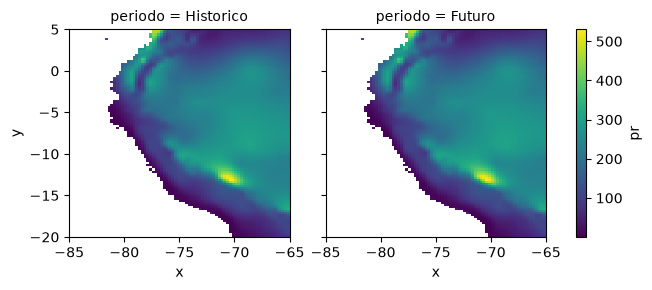

In [ ]:
ds_nuevo.sel(modelo="MPI-ESM1-2-LR",escenario="ssp245",season="DJF").plot(col="periodo")

plt.savefig('exploracion.png',dpi=300, bbox_inches="tight")
plt.show()

## PARTE II

### Ejercicio 1
Calcular las anomalías en "ds_base" respecto al periodo base 1985-2014

In [49]:
periodo_base = (1985, 2014)  # años inicio y fin, ambos incluidos

def calcular_climatologia_anomalia(da, periodo_base):
    # Se asigna el valor de la tupla a variables diferentes
    inicio, fin = periodo_base
    # Se selecciona la data correspondiente al periodo de tiempo definido (histórico), tomando todos
    # los años completos
    base = da.sel(time=slice(f"{inicio}-01-01", f"{fin}-12-31"))
    # Se agrupan los datos por mes y se promedian los datos de mes de cada año, devolviendo una data
    # con 12 variables
    climatologia = base.groupby("time.month").mean("time")
    # La anomalía se calcula de toda la data (incluyendo proyecciones) agrupada por mes y restada con la
    # climatología promedio de cada mes correspondiente
    anomalia = da.groupby("time.month") - climatologia
    return climatologia, anomalia

clim, anom = calcular_climatologia_anomalia(ds_base, periodo_base)

In [118]:
anom

<xarray.DataArray 'pr' (modelo: 3, escenario: 2, time: 1800, y: 100, x: 80)> Size: 346MB
array([[[[[            nan,             nan,             nan, ...,
           -3.81778183e+01, -4.06166000e+01, -4.28297501e+01],
          [            nan,             nan,             nan, ...,
           -4.03316345e+01, -4.27746582e+01, -4.49601707e+01],
          [            nan,             nan,             nan, ...,
           -4.15285645e+01, -4.41516953e+01, -4.63939400e+01],
          ...,
          [            nan,             nan,             nan, ...,
           -4.76043510e+01, -5.56473694e+01, -6.18704758e+01],
          [            nan,             nan,             nan, ...,
           -4.18838654e+01, -4.81368675e+01, -5.45106735e+01],
          [            nan,             nan,             nan, ...,
           -3.81758537e+01, -4.29410896e+01, -4.89039536e+01]],

         [[            nan,             nan,             nan, ...,
           -1.22587547e+01, -1.08007774e+01, -9.17077255e+00],
          [            nan,             nan,             nan, ...,
           -1.04475479e+01, -9.22476196e+00, -8.02159882e+00],
          [            nan,             nan,             nan, ...,
           -1.27467651e+01, -1.16796570e+01, -1.07876358e+01],
...
            3.16941185e+01,  4.96946793e+01,  6.76888580e+01],
          [            nan,             nan,             nan, ...,
            2.97226791e+01,  4.77190704e+01,  6.62636566e+01],
          [            nan,             nan,             nan, ...,
            2.88427773e+01,  4.56006775e+01,  6.39914703e+01]],

         [[            nan,             nan,             nan, ...,
           -8.66332245e+01, -9.07506256e+01, -9.47647552e+01],
          [            nan,             nan,             nan, ...,
           -8.23958588e+01, -8.67269440e+01, -9.15533676e+01],
          [            nan,             nan,             nan, ...,
           -7.57250824e+01, -8.11944427e+01, -8.74856873e+01],
          ...,
          [            nan,             nan,             nan, ...,
            6.38699722e+01,  7.69527130e+01,  8.71485138e+01],
          [            nan,             nan,             nan, ...,
            5.43497772e+01,  6.46210175e+01,  7.42693787e+01],
          [            nan,             nan,             nan, ...,
            4.72266388e+01,  5.50128860e+01,  6.36245804e+01]]]]],
      shape=(3, 2, 1800, 100, 80), dtype=float32)
Coordinates:
  * modelo     (modelo) <U13 156B 'MPI-ESM1-2-LR' 'NorESM2-LM' 'IPSL-CM6A-LR'
  * escenario  (escenario) <U6 48B 'ssp245' 'ssp585'
  * time       (time) datetime64[ns] 14kB 1950-01-01 1950-02-01 ... 2099-12-01
    month      (time) int64 14kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
  * y          (y) float64 800B 4.875 4.625 4.375 4.125 ... -19.38 -19.62 -19.88
  * x          (x) float64 640B -84.88 -84.62 -84.38 ... -65.62 -65.38 -65.12
Attributes:
    id:             pr
    data_type:      {'type': 'PixelType', 'precision': 'double'}
    crs:            EPSG:4326
    crs_transform:  [1 0 0 0 1 0]

### Ejercicio 2
Seleccionar la región 5°S-0°, 61°W-66°W y hacer un promedio espacial sobre las anomalías.

In [102]:
# Se define una función que recorta las coordenadas del dataArray y saca un promedio de los datos
def promedio_espacial(dataarray, lon_min=None, lon_max=None, lat_min=None, lat_max=None):
    # Recorte
    sub = dataarray
    if lon_min is not None or lon_max is not None:
        sub = sub.sel(x=slice(lon_min, lon_max))
    if lat_min is not None or lat_max is not None:
        sub = sub.sel(y=slice(lat_max, lat_min))

    # ponderamos por cos(lat): una celda cerca del ecuador cubre más área real
    # que una celda cerca de los 20°S, aunque ambas midan lo mismo en grados
    
    return sub.mean(dim=("y", "x"))

In [109]:
anom_prom = promedio_espacial(anom, lon_min=-5, lon_max=0, lat_min=-66, lat_max=-61)

In [110]:
anom_prom

<xarray.DataArray 'pr' (modelo: 3, escenario: 2, time: 1800)> Size: 43kB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(3, 2, 1800), dtype=float32)
Coordinates:
  * modelo     (modelo) <U13 156B 'MPI-ESM1-2-LR' 'NorESM2-LM' 'IPSL-CM6A-LR'
  * escenario  (escenario) <U6 48B 'ssp245' 'ssp585'
  * time       (time) datetime64[ns] 14kB 1950-01-01 1950-02-01 ... 2099-12-01
    month      (time) int64 14kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
Attributes:
    id:             pr
    data_type:      {'type': 'PixelType', 'precision': 'double'}
    crs:            EPSG:4326
    crs_transform:  [1 0 0 0 1 0]

### Ejercicio 3
A partir del cálculo anterior, selecciona solo los meses de tu estación asignada y obtén una serie con un valor por año. Pista: ds.sel(time=ds.time.dt.season=='ABC') 

In [111]:
serie_anual = anom_prom.sel(time=anom_prom.time.dt.season=='DJF').groupby("time.year").mean()

In [117]:
serie_anual.values

array([[[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,

### Ejercicio 4
Graficar, para cada escenario, la media del ensamble (3 modelos) junto con el rango entre modelos (mínimo-máximo). Editar apropiadamente el título y las etiquetas de los ejes.

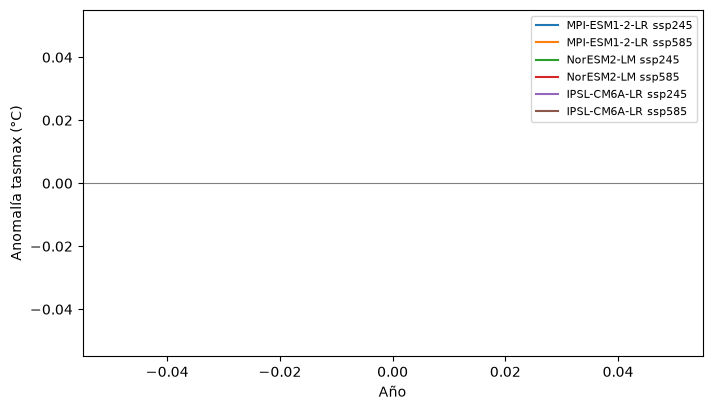

In [113]:
fig, ax = plt.subplots(figsize=(8, 4.5))

for modelo in serie_anual.modelo.values:
    for escenario in serie_anual.escenario.values:
        serie = serie_anual.sel(modelo=modelo, escenario=escenario)
        ax.plot(serie["year"], serie.values,
            label=f"{modelo} {escenario}")

ax.axhline(0, color="grey", lw=0.8)
ax.set_xlabel("Año")
ax.set_ylabel("Anomalía tasmax (°C)")
ax.legend(fontsize=8)
plt.show()